<a href="https://colab.research.google.com/github/DigdinLogistico/LOG-FATEC-INFORMATICA-1-SEM-2026/blob/main/Regress%C3%A3o_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("athiramolps/ice-cream-sales-and-temperature")

print("Path to dataset files:", path)

100%|██████████| 530/530 [00:00<00:00, 1.08MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/athiramolps/ice-cream-sales-and-temperature/versions/1


In [3]:
import pandas as pd

In [9]:
# Display general information about the DataFrame
print("\nDataFrame Information:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Date                   45 non-null     object
 1   Time                   45 non-null     object
 2   Temperature (Celsius)  45 non-null     int64 
 3   Ice Cream Sales        45 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 1.5+ KB

Descriptive Statistics:
       Temperature (Celsius)  Ice Cream Sales
count              45.000000        45.000000
mean               40.000000        19.511111
std                13.133926        10.552083
min                18.000000         0.000000
25%                29.000000        11.000000
50%                40.000000        21.000000
75%                51.000000        28.000000
max                62.000000        38.000000


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare the data
X = df[['Temperature (Celsius)']]
y = df['Ice Cream Sales']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nLinear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Print the model coefficients
print(f"\nModel Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")


Linear Regression Model Performance:
Mean Absolute Error (MAE): 3.70
Mean Squared Error (MSE): 16.94
Root Mean Squared Error (RMSE): 4.12
R-squared (R2): 0.88

Model Coefficient (Slope): -0.67
Model Intercept: 46.50


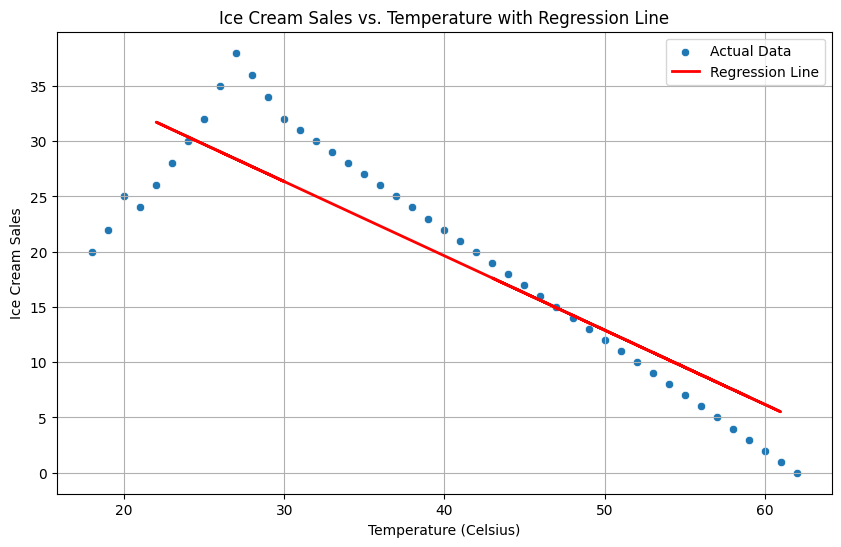

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the regression line on the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature (Celsius)', y='Ice Cream Sales', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Ice Cream Sales vs. Temperature with Regression Line')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Ice Cream Sales')
plt.grid(True)
plt.legend()
plt.show()

In [12]:
print(f"Model Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")

Model Coefficient (Slope): -0.67
Model Intercept: 46.50
